# Step 1.1 — Camera Preprocessing (Upgraded) ✅

| | |
|---|---|
| **Input** | `output/step_0/samples_index.json`, `sensor_meta.json` per sample |
| **Outputs** | `output/step_1/camera_meta.json` — calibration + intrinsics per sample |
| | `output/step_1/camera_timestamp_report.json` — validity report |
| | `output/step_1/projection_check_<sample>.png` — visual proof of projection correctness |
| **New in this version** | `project_point_to_camera()` — the missing piece that lets you project ANY 3D point (LiDAR cluster, radar detection, fused UKF object) onto ANY camera view, correctly, even though sensors fire at slightly different timestamps |
| **Used by** | Step 4.3 (camera tracking), Step 4.4 (fusion), Step 6 (visualization) |

---

### Why this upgrade exists
The original notebook collected calibration data (translation, rotation, intrinsics) but never actually **used** it to project a 3D point onto an image. This meant every downstream fusion step that tried to draw LiDAR/radar detections onto camera images had no correct way to do it — points would be computed using only one sensor's ego_pose, ignoring that the car moves between each sensor's capture timestamp. This version adds the full 5-step transform chain and a visual sanity check.

In [1]:
# ─────────────────────────────────────────────────────────────────
# CELL 1 — Verify config.py exists
# ─────────────────────────────────────────────────────────────────

from pathlib import Path

if not Path("config.py").exists():
    raise FileNotFoundError(
        "config.py not found in this folder. Copy it from the repo root "
        "and set DATA_ROOT to your nuScenes dataset path."
    )

from config import DATA_ROOT, NUSCENES_VERSION, STEP0_DIR, STEP1_DIR

if not DATA_ROOT.exists():
    raise FileNotFoundError(f"DATA_ROOT does not exist: {DATA_ROOT}")

print(f"✅ config.py found")
print(f"✅ DATA_ROOT : {DATA_ROOT}")
print(f"✅ STEP0_DIR : {STEP0_DIR}")
print(f"✅ STEP1_DIR : {STEP1_DIR}")

config.py loaded. PROJECT_ROOT = F:\Sensor fusion Research
DATA_ROOT   = F:\Sensor fusion Research\DATA SET\archive
OUTPUT_ROOT = F:\Sensor fusion Research\output
✅ config.py found
✅ DATA_ROOT : F:\Sensor fusion Research\DATA SET\archive
✅ STEP0_DIR : F:\Sensor fusion Research\output\step_0
✅ STEP1_DIR : F:\Sensor fusion Research\output\step_1


In [2]:
# ─────────────────────────────────────────────────────────────────
# CELL 2 — Main pipeline: parse camera metadata + intrinsics
# FIXED: folder path now joins with STEP0_DIR (matches new Step 0 output)
# FIXED: removed broken syntax (stray text was inside the dict literal)
# ─────────────────────────────────────────────────────────────────

from nuscenes.nuscenes import NuScenes
import json

nusc = NuScenes(version=NUSCENES_VERSION, dataroot=str(DATA_ROOT), verbose=False)

with open(STEP0_DIR / "samples_index.json") as f:
    samples_index = json.load(f)

camera_data = {}

for sample_id, sample_info in samples_index.items():
    # FIXED — join with STEP0_DIR since "folder" is now a relative name
    sensor_meta_path = STEP0_DIR / sample_info["folder"] / "sensor_meta.json"
    with open(sensor_meta_path) as f:
        sensor_meta = json.load(f)

    cam_views = {}
    for channel, meta in sensor_meta["sensor_channels"].items():
        if meta["modality"] != "camera":
            continue

        cs = nusc.get('calibrated_sensor', meta["calibrated_sensor_token"])

        cam_views[channel] = {
            "filename": meta["filename"],
            "timestamp": meta["timestamp"],
            "ego_pose": meta["ego_pose"],
            "calibrated_sensor": {
                "translation": meta["sensor_to_ego_translation"],
                "rotation": meta["sensor_to_ego_rotation"],
                "camera_intrinsic": cs["camera_intrinsic"]
            }
        }

    if cam_views:
        camera_data[sample_id] = cam_views

output_file = STEP1_DIR / "camera_meta.json"
with open(output_file, "w") as f:
    json.dump(camera_data, f, indent=2)

assert len(camera_data) == len(samples_index), \
    f"Expected {len(samples_index)} samples with camera data, got {len(camera_data)}"

print(f"✅ Step 1.1 complete: {len(camera_data)} samples processed.")
print(f"📄 Saved to: {output_file}")

✅ Step 1.1 complete: 404 samples processed.
📄 Saved to: F:\Sensor fusion Research\output\step_1\camera_meta.json


## 🎯 NEW: The projection utility

This is the piece that was missing. It takes a 3D point from ANY sensor frame (LiDAR, radar, or a fused global-frame object from your UKF) and correctly projects it onto ANY camera's image plane — properly bridging through the global frame so the car's motion between sensor timestamps is accounted for.

**Reuse this function in Step 4.3 (camera tracking) and Step 4.4 (fusion) — it's the piece those notebooks need to draw fused objects onto camera images correctly.**

In [3]:
# ─────────────────────────────────────────────────────────────────
# CELL 3 — Projection utility: 3D point (any sensor frame) → camera pixel
# ─────────────────────────────────────────────────────────────────

import numpy as np
from pyquaternion import Quaternion


def transform_matrix(translation, rotation_quat, inverse=False):
    """
    Builds a 4x4 homogeneous transform matrix from a translation vector
    and a quaternion [w, x, y, z] (nuScenes quaternion convention).

    If inverse=True, returns the inverse transform (used when going
    FROM global back INTO a sensor frame — e.g. global -> camera's ego).
    """
    rot = Quaternion(rotation_quat)
    tm = np.eye(4)

    if inverse:
        rot_inv = rot.inverse
        tm[:3, :3] = rot_inv.rotation_matrix
        tm[:3, 3] = -(rot_inv.rotation_matrix @ np.array(translation))
    else:
        tm[:3, :3] = rot.rotation_matrix
        tm[:3, 3] = translation

    return tm


def project_point_to_camera(point_xyz,
                              src_ego_pose, src_calibrated_sensor,
                              cam_ego_pose, cam_calibrated_sensor,
                              camera_intrinsic,
                              image_width=1600, image_height=900):
    """
    Projects a single 3D point from a SOURCE sensor's frame (e.g. LiDAR,
    radar, or a fused UKF state in global frame) into a TARGET camera's
    image plane.

    This is the 5-step chain that was missing from the original pipeline:
      1. source sensor frame -> ego frame        (at SOURCE timestamp)
      2. ego frame -> global frame                (at SOURCE timestamp)
      3. global frame -> ego frame                (at CAMERA timestamp — bridges the time gap)
      4. ego frame -> camera sensor frame          (at CAMERA timestamp)
      5. camera 3D point -> image pixel            (using camera_intrinsic)

    Returns:
        (u, v, depth) if the point is in front of the camera and depth > 0
        None if the point is behind the camera (invalid projection)
    """
    point = np.array(point_xyz, dtype=float).reshape(3, 1)
    point_h = np.vstack([point, [[1.0]]])

    # 1. source sensor -> ego (at source timestamp)
    T1 = transform_matrix(src_calibrated_sensor["translation"],
                           src_calibrated_sensor["rotation"])
    point_h = T1 @ point_h

    # 2. ego -> global (at source timestamp)
    T2 = transform_matrix(src_ego_pose["translation"],
                           src_ego_pose["rotation"])
    point_h = T2 @ point_h

    # 3. global -> ego (at CAMERA timestamp) — bridges the sensor time gap
    T3 = transform_matrix(cam_ego_pose["translation"],
                           cam_ego_pose["rotation"], inverse=True)
    point_h = T3 @ point_h

    # 4. ego -> camera sensor frame (at camera timestamp)
    T4 = transform_matrix(cam_calibrated_sensor["translation"],
                           cam_calibrated_sensor["rotation"], inverse=True)
    point_h = T4 @ point_h

    point_cam = point_h[:3]
    depth = float(point_cam[2, 0])

    if depth <= 0:
        return None  # point is behind the camera — do not project

    # 5. camera 3D -> image pixel using intrinsic matrix
    K = np.array(camera_intrinsic)
    pixel = K @ point_cam
    u = float(pixel[0, 0] / pixel[2, 0])
    v = float(pixel[1, 0] / pixel[2, 0])

    if not (0 <= u < image_width and 0 <= v < image_height):
        return None  # projects outside the visible image — discard

    return (u, v, depth)


print("✅ Projection utility loaded: transform_matrix(), project_point_to_camera()")

✅ Projection utility loaded: transform_matrix(), project_point_to_camera()


## 🔍 Visual proof: project real LiDAR points onto CAM_FRONT

If the projection chain above is correct, LiDAR points should land exactly on the road surface and on objects (cars, curbs, poles) in the camera image — not drift off to the side. This is the check to run every time you touch the projection logic.

✅ Projected 1017 / 11563 points onto CAM_FRONT (8.8% landed inside the image)


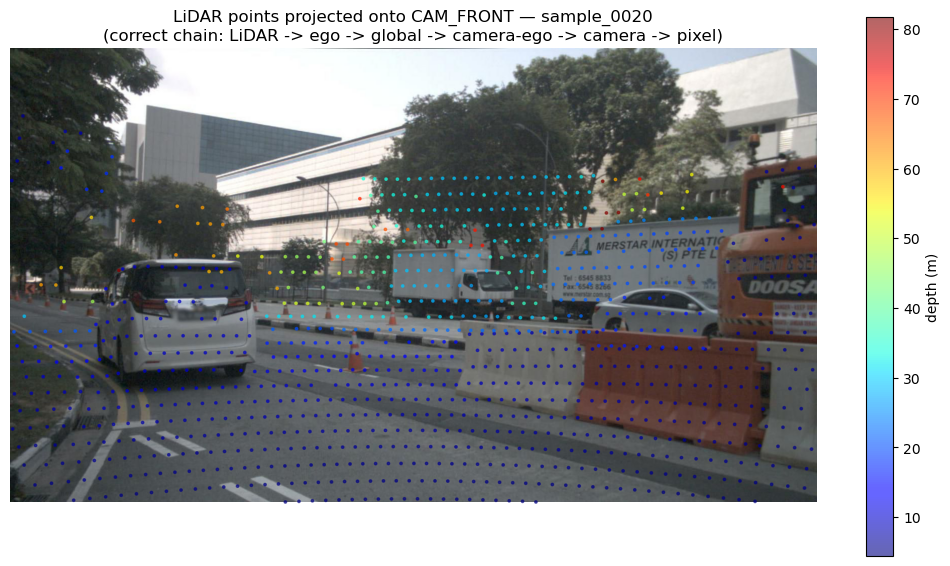

📄 Saved visual check to: F:\Sensor fusion Research\output\step_1\projection_check_sample_0020.png

If points hug the road surface and outline vehicles/curbs correctly,
your projection chain is now correct and safe to reuse in Step 4.3 / 4.4.


In [7]:
# ─────────────────────────────────────────────────────────────────
# CELL 4 — Visual validation: overlay real LiDAR points onto CAM_FRONT
# ─────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
from PIL import Image
from nuscenes.utils.data_classes import LidarPointCloud

sample_id = "sample_0020"   # ← change to check any sample

sensor_meta_path = STEP0_DIR / samples_index[sample_id]["folder"] / "sensor_meta.json"
with open(sensor_meta_path) as f:
    sensor_meta = json.load(f)

lidar_meta = sensor_meta["sensor_channels"]["LIDAR_TOP"]
cam_meta   = sensor_meta["sensor_channels"]["CAM_FRONT"]

# Load raw LiDAR points (in LiDAR sensor frame)
lidar_path = DATA_ROOT / lidar_meta["filename"]
pc = LidarPointCloud.from_file(str(lidar_path))
points = pc.points[:3, :].T   # shape (N, 3)

# Camera intrinsic for CAM_FRONT
cs_cam = nusc.get('calibrated_sensor', cam_meta["calibrated_sensor_token"])
camera_intrinsic = cs_cam["camera_intrinsic"]

src_calibrated_sensor = {
    "translation": lidar_meta["sensor_to_ego_translation"],
    "rotation": lidar_meta["sensor_to_ego_rotation"]
}
src_ego_pose = lidar_meta["ego_pose"]
cam_calibrated_sensor = {
    "translation": cam_meta["sensor_to_ego_translation"],
    "rotation": cam_meta["sensor_to_ego_rotation"]
}
cam_ego_pose = cam_meta["ego_pose"]

# Project every 3rd point (for speed) using OUR function
results = []
for p in points[::3]:
    r = project_point_to_camera(
        p, src_ego_pose, src_calibrated_sensor,
        cam_ego_pose, cam_calibrated_sensor, camera_intrinsic
    )
    if r is not None:
        results.append(r)

results = np.array(results)
print(f"✅ Projected {len(results)} / {len(points[::3])} points onto CAM_FRONT "
      f"({len(results)/len(points[::3])*100:.1f}% landed inside the image)")

# Overlay on the actual camera image
img_path = DATA_ROOT / cam_meta["filename"]
img = Image.open(img_path)

plt.figure(figsize=(13, 7))
plt.imshow(img)
sc = plt.scatter(results[:, 0], results[:, 1], c=results[:, 2],
                  cmap='jet', s=3, alpha=0.6)
plt.colorbar(sc, label='depth (m)')
plt.title(f"LiDAR points projected onto CAM_FRONT — {sample_id}\n"
          f"(correct chain: LiDAR -> ego -> global -> camera-ego -> camera -> pixel)")
plt.axis('off')

save_path = STEP1_DIR / f"projection_check_{sample_id}.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"📄 Saved visual check to: {save_path}")
print("\nIf points hug the road surface and outline vehicles/curbs correctly,")
print("your projection chain is now correct and safe to reuse in Step 4.3 / 4.4.")

## Data quality checks (kept from original, paths fixed)

In [5]:
# ─────────────────────────────────────────────────────────────────
# CELL 5 — Check all 6 camera channels are present per sample
# ─────────────────────────────────────────────────────────────────

with open(STEP1_DIR / "camera_meta.json") as f:
    camera_data = json.load(f)

expected_channels = {
    "CAM_FRONT", "CAM_FRONT_LEFT", "CAM_FRONT_RIGHT",
    "CAM_BACK", "CAM_BACK_LEFT", "CAM_BACK_RIGHT"
}

missing_channels = {}
for sample_id, cams in camera_data.items():
    missing = expected_channels - set(cams.keys())
    if missing:
        missing_channels[sample_id] = list(missing)

if not missing_channels:
    print("✅ All samples have all 6 camera channels.")
else:
    print(f"⚠️ {len(missing_channels)} samples are missing camera views:")
    for sid, missing in sorted(missing_channels.items()):
        print(f"  - {sid}: missing {missing}")

✅ All samples have all 6 camera channels.


In [6]:
# ─────────────────────────────────────────────────────────────────
# CELL 6 — Timestamp validity check across all 6 cameras
# ─────────────────────────────────────────────────────────────────

complete_samples = []
partial_samples = {}

expected_cams = ["CAM_FRONT", "CAM_FRONT_RIGHT", "CAM_BACK_RIGHT",
                  "CAM_BACK", "CAM_BACK_LEFT", "CAM_FRONT_LEFT"]

for sample_id, cams in camera_data.items():
    missing = [cam for cam in expected_cams
               if not isinstance(cams.get(cam, {}).get("timestamp"), int)]
    if missing:
        partial_samples[sample_id] = missing
    else:
        complete_samples.append(sample_id)

print(f"🔢 Total samples: {len(camera_data)}")
print(f"✅ Fully valid (all 6 cameras have timestamp): {len(complete_samples)}")
print(f"⚠️ Partially missing: {len(partial_samples)}")

report_path = STEP1_DIR / "camera_timestamp_report.json"
with open(report_path, "w") as f:
    json.dump({
        "fully_valid_samples": complete_samples,
        "partially_missing_samples": partial_samples
    }, f, indent=2)

print(f"📝 Report saved to: {report_path}")

🔢 Total samples: 404
✅ Fully valid (all 6 cameras have timestamp): 404
⚠️ Partially missing: 0
📝 Report saved to: F:\Sensor fusion Research\output\step_1\camera_timestamp_report.json
